(3212, 18)


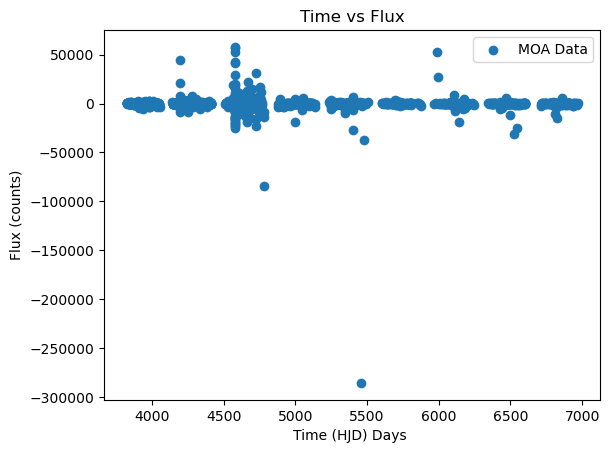

(3201, 18)


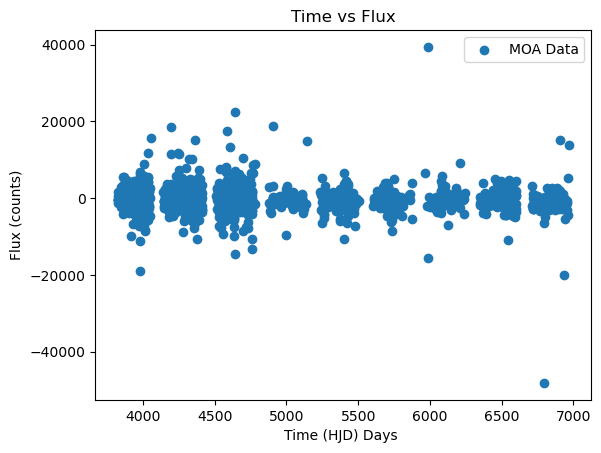

(3202, 18)


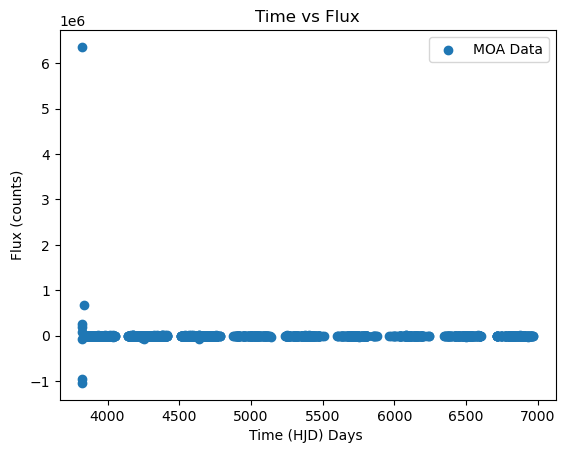

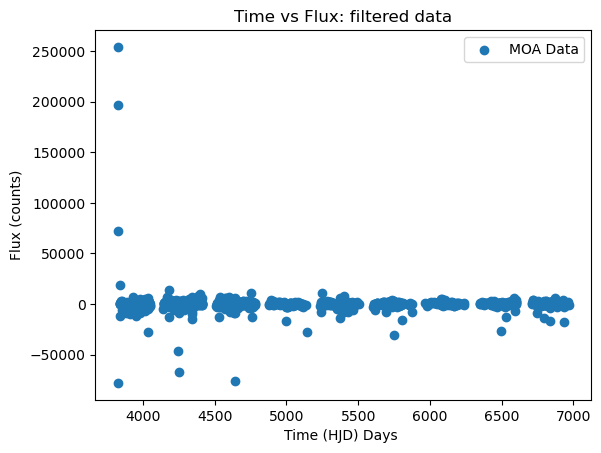

Reduced Chi-Squared: 21804616.22


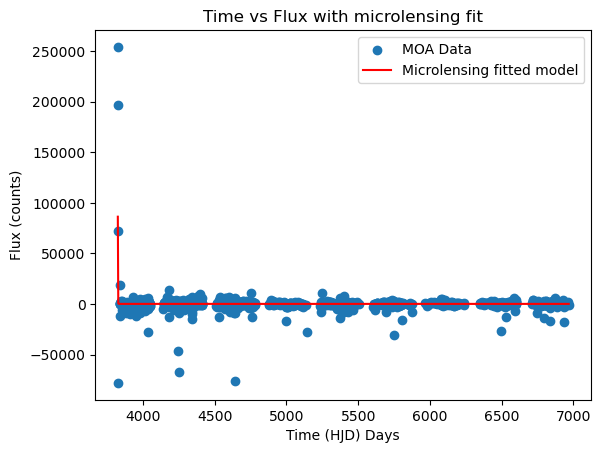

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip #the files arestored as .gz so this is how i will open them 
import tarfile
from astropy.table import Table 
from scipy.optimize import curve_fit
tar_path = "/Users/gracef/python_decal/grace/gb22.tar"
#file path on my personal computer 
df = None
#define the variable globally so then i can use it later
random_file = "gb22-R-8-5-21694"
another_random_file = "gb22-R-8-1-6355.ipac.gz"
#there are so many files so I am picking one to look at 
#with tarfile.open(tar_path, "r:*") as tar:
    #importing the tar file and extracting one file from it
    #good because the file is super large so good to look at small chunks 
    #for member in tar.getmembers()[:5]:
        #print(memner.name)
#printing some files in order to see how they are stored because the file is too large
def graphing_MOA_data(file_name):
    with tarfile.open(tar_path, "r:") as tar:
        for member in tar.getmembers():
            if file_name in member.name:
                #only going to look at this one file because theres too much data
                file = tar.extractfile(member)
                #extract the .ipac.gz files
                
                with gzip.open(file, "rt") as gz:
                    data = gz.read()
                    #read the file 
                    table = Table.read(data, format="ascii.ipac")
                    df = table.to_pandas()
                #print(member.name)
    #inpecting the data frame of this partifular file 
    print(df.shape)
    #3201 rows and 18 columns 
    #original columns : Index(['HJD', 'flux', 'cor_flux', 'flux_err', 'obsID', 'JD', 'fwhm', 'sky',
            #'airmass', 'nstar', 'scale', 'exptime', 'skydiff', 'chisq', 'npix',
            #'airmass1', 'ang1', 'included'],
    
    #cleaning the data
    df = df[["HJD", "flux", "flux_err"]] #I only want these three columns, we can ignore the rest 
    #so now instead of 18 columns there are 3
    time = df["HJD"]
    #HJD is the heliocentric julian date, it is the time of an event relative to the sun instead of relative to earth 
    flux = df["flux"]
    #the flux is the observed brightness 
    flux_error = df["flux_err"]
    #print(df.head)

    #okay lets start graphing! 
    #main plot: time vs flux 
    plt.scatter(time, flux, label="MOA Data")
    plt.xlabel("Time (HJD) Days ")
    plt.ylabel("Flux (counts)")
    plt.title("Time vs Flux")
    plt.legend()
    plt.show()
    return df
    
def find_best_data(max_files=50):
    best_score = -np.inf
    best_df = None
    best_file = None 
    count = 0
    with tarfile.open(tar_path, "r:") as tar:
        for member in tar.getmembers():
            if member.isfile() and member.name.endswith("ipac.gz"):
                file = tar.extractfile(member)
                #extract the .ipac.gz files
            try:
                with gzip.open(file, "rt") as gz:
                        data = gz.read()
                        #read the file 
                        table = Table.read(data, format="ascii.ipac")
                        df_temp = table.to_pandas()
            except:
                continue
            if len(df_temp) < 100:
                continue 
            df_temp = df_temp[["HJD", "flux", "flux_err"]]
    
            flux = df_temp["flux"].values
            baseline = np.median(flux)
            noise = np.std(flux)
            peak = np.max(flux)
                #calculate the best score by figuring out which file has a clear peak
                #because that is the most likeley to be a microlensing event 
            if noise == 0: #don't want noisy data 
                continue
            score = (peak - baseline)/noise
            if score > best_score: 
                best_score = score 
                best_df = df_temp.copy()
                best_file = member.name
            count += 1
            if count >= max_files:
                break
    return best_df, best_file
best_df, best_file = find_best_data(max_files=50)


def filtered_data(max_files = 50):
    #I want less extreme poiints, so this will filture through sets with points within five standard deviations 
    best_score_no = -np.inf
    best_df_no = None
    best_file_no = None 
    count = 0
    with tarfile.open(tar_path, "r:") as tar:
        for member in tar.getmembers():
            if member.isfile() and member.name.endswith("ipac.gz"):
                file = tar.extractfile(member)
                #extract the .ipac.gz files
                try:
                    with gzip.open(file, "rt") as gz:
                            data = gz.read()
                            #read the file 
                            table = Table.read(data, format="ascii.ipac")
                            df_temp = table.to_pandas()
                except:
                    continue
                if len(df_temp) < 100:
                    continue 
                #remove outliers 
                median = df_temp["flux"].median()
                std = df_temp["flux"].std()
                
    
                df_temp = df_temp[np.abs(df_temp["flux"] - median) < 5*std]
                flux = df_temp["flux"].values
                baseline = np.median(flux)
                noise = np.std(flux)
                peak = np.max(flux)
                    #calculate the best score by figuring out which file has a clear peak
                    #because that is the most likeley to be a microlensing event 
                if noise == 0: #don't want noisy data 
                    continue
                score = (peak - baseline)/noise
                if score > best_score_no: 
                    best_score_no = score 
                    best_df_no = df_temp.copy()
                    best_file_no = member.name
                count += 1
                if count >= max_files:
                    break
    return best_df_no, best_file_no
best_df, best_file = find_best_data(max_files=50)
best_df_no, best_file_no = filtered_data(max_files=50)
df1 = graphing_MOA_data(random_file)
df2 = graphing_MOA_data(another_random_file)
df3 = graphing_MOA_data(best_file)
plt.scatter(best_df_no["HJD"], best_df_no["flux"], label="MOA Data")
plt.xlabel("Time (HJD) Days ")
plt.ylabel("Flux (counts)")
plt.title("Time vs Flux: filtered data")
plt.legend()
plt.show()

#lets compare this to the model equations 
#define the model we want to compare 
def micro_lensing_model(t, F0, Fs, u0, t0, tE):
    #Fs is the blending parameter 
    #t is time 
    #F0 is the baseline flux 
    #uo is the impact parameter 
    #tE is the einstien radius crossing timescale 
    #t0 is the peak time
    #defines the variables used in the two equations of interest 
    u = np.sqrt(((t-t0)/tE)**2+u0**2)
    #source lens separation in angular einstien radii unit 
    A = (u**2+2)/(u*np.sqrt(u**2+4))
    #this equation measures the magnification by using the sourse lense separation we calculated 
    return F0*(1+Fs*(A-1))
#lets fit it to the one that has no outliers 
#define globally 
time = best_df_no["HJD"]
flux = best_df_no["flux"]

#guesses 
F0_guess = np.median(flux) 
#median brightness 
Fs_guess = 1
#assuming that all light comes from the star, not any bending of the light 
u0_guess = .3 
#middle vule for the magnification 
t0_guess = time[np.argmax(flux)]
#when does the peak brightness(flux) occur 
tE_guess = 50
#common length for microlensing event lengths (in days)

#fitting the model 
p0 = [F0_guess, Fs_guess, u0_guess, t0_guess, tE_guess]
bounds = ([-np.inf, 0, 0.01, time.min(), 1],[ np.inf, np.inf, 5, time.max(), 1000])
#highest and lowest values 
popt, pcov = curve_fit(micro_lensing_model, time, flux, p0=p0, bounds=bounds, maxfev = 5000)
F0_fit, Fs_fit, u0_fit, t0_fit, tE_fit = popt


time_fit = np.linspace(time.min(), time.max(), 1000)
flux_fit = micro_lensing_model(time_fit, F0_fit, Fs_fit, u0_fit, t0_fit, tE_fit)

residuals = flux - micro_lensing_model(time, F0_fit, Fs_fit, u0_fit, t0_fit, tE_fit)
chi2 = np.sum(residuals**2)
dof = len(time) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")

plt.scatter(time, flux, label="MOA Data ")
plt.plot(time_fit, flux_fit, color = "red", label = "Microlensing fitted model")
plt.xlabel("Time (HJD) Days")
plt.ylabel("Flux (counts)")
plt.title("Time vs Flux with microlensing fit")
plt.legend()
plt.show()
